## Second Order Cone Programming
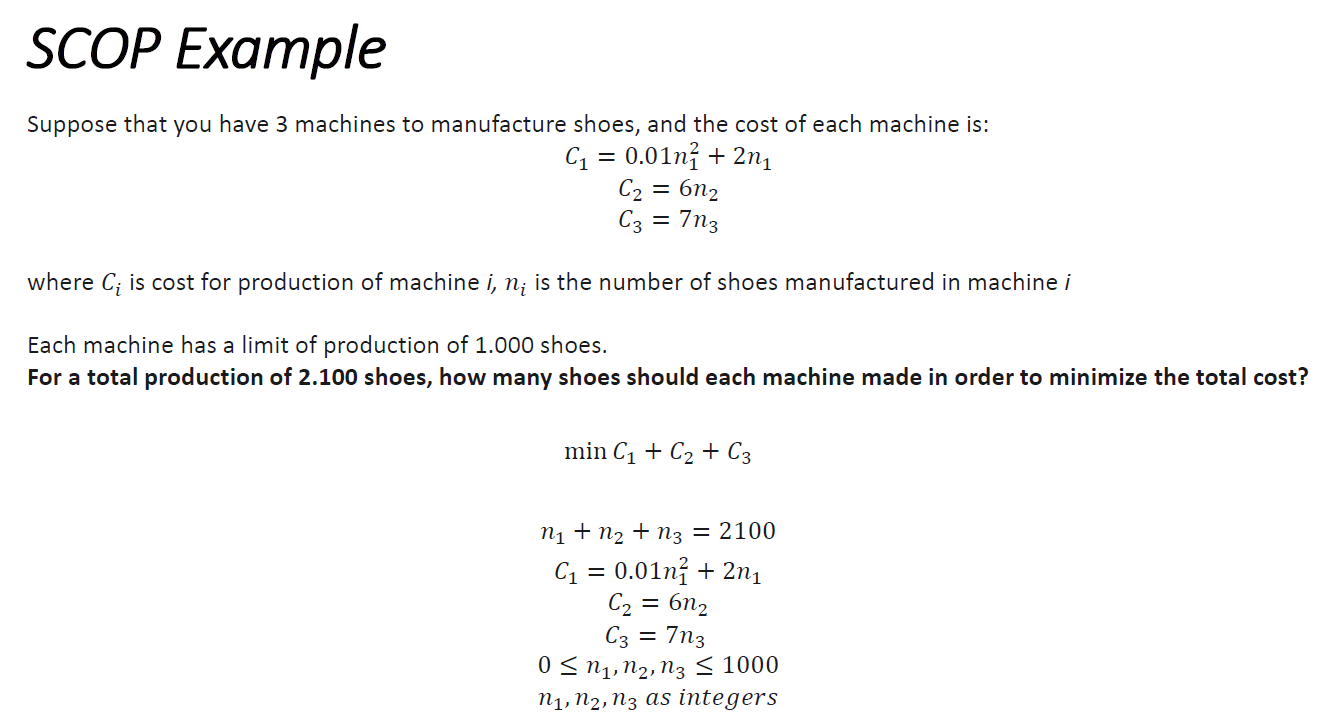

In [1]:
import pyomo.environ as pyo, numpy as np
from pyomo.environ import *
from pyomo.opt import SolverFactory

#creation of the model and variables
model = pyo.ConcreteModel()
model.C = pyo.Var(range(1,4))
model.n = pyo.Var(range(1,4), within=Integers, bounds=(0,1000))
C = model.C
n = model.n

#objective function
model.obj = pyo.Objective(expr = pyo.summation(C))

#constraint
model.total = pyo.Constraint(expr = pyo.summation(n) == 2100)
model.C1 = pyo.Constraint(expr = C[1] == 0.01*n[1]**2 + 2*n[1])
model.C2 = pyo.Constraint(expr = C[2] == 6*n[2])
model.C3 = pyo.Constraint(expr = C[3] == 7*n[3])

#solve
opt = SolverFactory('gurobi')
opt.solve(model)

#print
print('n1', pyo.value(n[1]))
print('n2', pyo.value(n[2]))
print('n3', pyo.value(n[3]))
print('nTotal', pyo.value(pyo.summation(n)))

print('C1', pyo.value(C[1]))
print('C2', pyo.value(C[2]))
print('C3', pyo.value(C[3]))
print('CTotal', pyo.value(pyo.summation(C)))

n1 250.0
n2 1000.0
n3 850.0
nTotal 2100.0
C1 1125.0
C2 6000.0
C3 5950.0
CTotal 13075.0


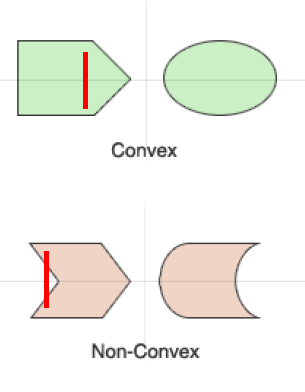

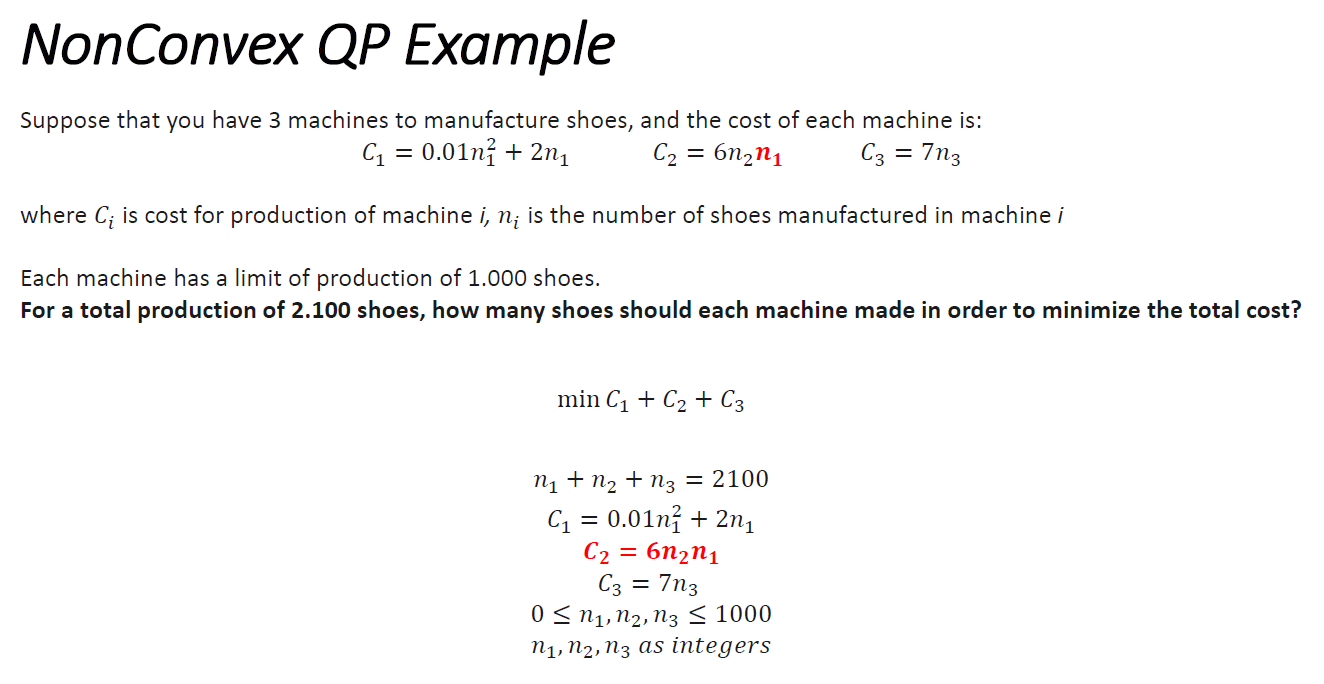

In [2]:
import pyomo.environ as pyo, numpy as np
from pyomo.environ import *
from pyomo.opt import SolverFactory

#creation of the model and variables
model = pyo.ConcreteModel()
model.C = pyo.Var(range(1,4))
model.n = pyo.Var(range(1,4), within=Integers, bounds=(0,1000))
C = model.C
n = model.n

#objective function
model.obj = pyo.Objective(expr = pyo.summation(C))

#constraint
model.total = pyo.Constraint(expr = pyo.summation(n) == 2100)
model.C1 = pyo.Constraint(expr = C[1] == 0.01*n[1]*n[1] + 2*n[1])
model.C2 = pyo.Constraint(expr = C[2] == 6*n[2]*n[1])
model.C3 = pyo.Constraint(expr = C[3] == 7*n[3])

#solve
opt = SolverFactory('gurobi')
# 關鍵可以處理非凸集合
opt.options['NonConvex'] = 2
opt.solve(model)

#print
print('n1', pyo.value(n[1]))
print('n2', pyo.value(n[2]))
print('n3', pyo.value(n[3]))
print('nTotal', pyo.value(pyo.summation(n)))

print('C1', pyo.value(C[1]))
print('C2', pyo.value(C[2]))
print('C3', pyo.value(C[3]))
print('CTotal', pyo.value(pyo.summation(C)))

n1 100.0
n2 1000.0
n3 1000.0
nTotal 2100.0
C1 300.0
C2 600000.0
C3 7000.0
CTotal 607300.0


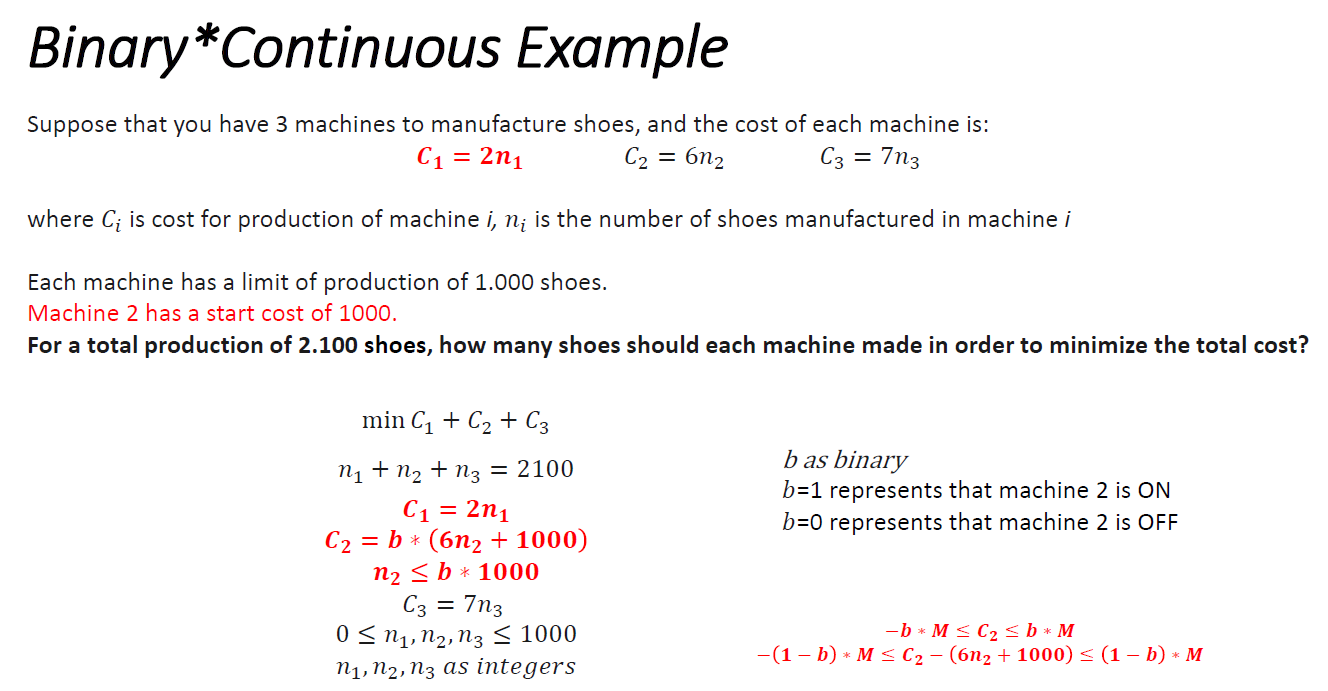

In [3]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

#creation of the model and variables
model = pyo.ConcreteModel()
model.C = pyo.Var(range(1,4))
model.n = pyo.Var(range(1,4), within=Integers, bounds=(0,1000))
model.b = pyo.Var(within=Binary)
C = model.C
n = model.n
b = model.b

#objective function
model.obj = pyo.Objective(expr = pyo.summation(C))

#constraint
model.total = pyo.Constraint(expr = pyo.summation(n) == 2100)
model.C1 = pyo.Constraint(expr = C[1] == 2*n[1])
model.C2 = pyo.Constraint(expr = C[2] == b*(6*n[2]+1000))
model.C2n = pyo.Constraint(expr = n[2] <= b*1000)
model.C3 = pyo.Constraint(expr = C[3] == 7*n[3])

#solve
opt = SolverFactory('gurobi')
opt.solve(model)

#print
print('n1', pyo.value(n[1]))
print('n2', pyo.value(n[2]))
print('n3', pyo.value(n[3]))
print('nTotal', pyo.value(pyo.summation(n)))

print('C1', pyo.value(C[1]))
print('C2', pyo.value(C[2]))
print('C3', pyo.value(C[3]))
print('CTotal', pyo.value(pyo.summation(C)))

n1 1000.0
n2 1000.0
n3 100.0
nTotal 2100.0
C1 2000.0
C2 7000.0
C3 700.0
CTotal 9700.0


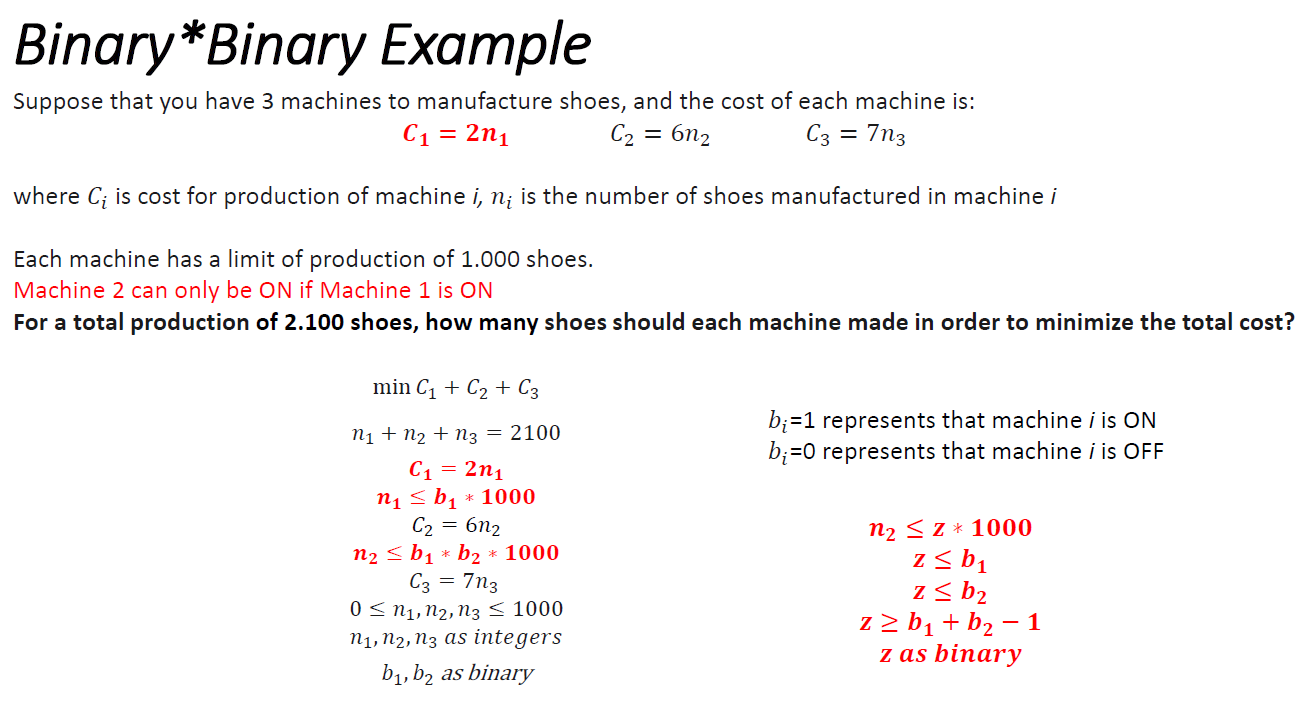

In [4]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

#creation of the model and variables
model = pyo.ConcreteModel()
model.C = pyo.Var(range(1,4))
model.n = pyo.Var(range(1,4), within=Integers, bounds=(0,1000))
model.b = pyo.Var(range(1,4),within=Binary)
C = model.C
n = model.n
b = model.b

#objective function
model.obj = pyo.Objective(expr = pyo.summation(C))

#constraint
model.total = pyo.Constraint(expr = pyo.summation(n) == 2100)
model.C1 = pyo.Constraint(expr = C[1] == 2*n[1])
model.C1n = pyo.Constraint(expr = n[1] <= b[1]*1000)
model.C2 = pyo.Constraint(expr = C[2] == 6*n[2])
model.C2n = pyo.Constraint(expr = n[2] <= b[1]*b[2]*1000)
model.C3 = pyo.Constraint(expr = C[3] == 7*n[3])

#solve
opt = SolverFactory('gurobi')
opt.solve(model)

#print
print('n1', pyo.value(n[1]))
print('n2', pyo.value(n[2]))
print('n3', pyo.value(n[3]))
print('nTotal', pyo.value(pyo.summation(n)))

print('\nb1', pyo.value(b[1]))
print('b2', pyo.value(b[2]))

print('\nC1', pyo.value(C[1]))
print('C2', pyo.value(C[2]))
print('C3', pyo.value(C[3]))
print('CTotal', pyo.value(pyo.summation(C)))

n1 1000.0
n2 1000.0
n3 100.0
nTotal 2100.0

b1 1.0
b2 1.0

C1 2000.0
C2 6000.0
C3 700.0
CTotal 8700.0


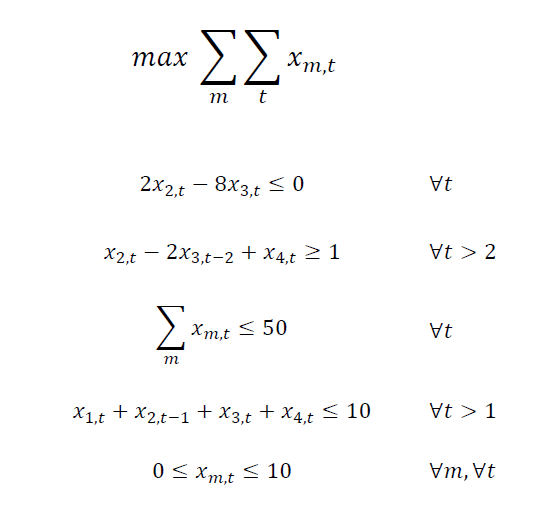

In [5]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(expr = x[m,t] <= 10)
        model.C5.add(expr = x[m,t] >= 0)

#solve
opt = SolverFactory('gurobi')
results = opt.solve(model)

model.pprint()

print('\nOptimal Solution: ' + str(pyo.value(model.obj)))

1 Var Declarations
    x : Size=40, Index={1, 2, 3, 4}*{1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
        Key     : Lower : Value : Upper : Fixed : Stale : Domain
         (1, 1) :  None :  10.0 :  None : False : False : Integers
         (1, 2) :  None :  10.0 :  None : False : False : Integers
         (1, 3) :  None :  -0.0 :  None : False : False : Integers
         (1, 4) :  None :  -0.0 :  None : False : False : Integers
         (1, 5) :  None :  -0.0 :  None : False : False : Integers
         (1, 6) :  None :  -0.0 :  None : False : False : Integers
         (1, 7) :  None :  -0.0 :  None : False : False : Integers
         (1, 8) :  None :  -0.0 :  None : False : False : Integers
         (1, 9) :  None :  -0.0 :  None : False : False : Integers
        (1, 10) :  None :  -0.0 :  None : False : False : Integers
         (2, 1) :  None :  -0.0 :  None : False : False : Integers
         (2, 2) :  None :  -0.0 :  None : False : False : Integers
         (2, 3) :  None :   9.0 :  None : Fa

features_solverProgress

In [6]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(expr = x[m,t] <= 10)
        model.C5.add(expr = x[m,t] >= 0)

#solve
opt = SolverFactory('gurobi')
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmp0q3u4wfj.pyomo.lp
Reading time = 0.00 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xbf2acea5
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: objective 113.0000000
Variable types: 0 continuous, 21 integer (0 binary)
Found heuristic solution: objective 124.000000

features_GAP

In [7]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(expr = x[m,t] <= 10)
        model.C5.add(expr = x[m,t] >= 0)

#solve
opt = SolverFactory('gurobi')
# opt.options['MIPgap'] = 0.05 會在第一次就收斂，最佳解會得到 124 (較差)
opt.options['MIPgap'] = 0
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmp4kzalfo1.pyomo.lp
Reading time = 0.02 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xbf2acea5
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: objective 113.0000000
Variable types: 0 continuous, 2

features_TimeLimit

In [8]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(expr = x[m,t] <= 10)
        model.C5.add(expr = x[m,t] >= 0)

#solve
opt = SolverFactory('gurobi')
opt.options['MIPgap'] = 0
# 若跑太久，可以設定 10 秒時間限制
opt.options['TimeLimit'] = 10
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmpeosi7d8_.pyomo.lp
Reading time = 0.00 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  10
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xbf2acea5
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: obj

Pyomo with SCIP solver

In [ ]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(expr = x[m,t] <= 10)
        model.C5.add(expr = x[m,t] >= 0)

#solve
## 需要去把 scipampl.exe 下載下來
opt = SolverFactory('scipampl')
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

SCIP version 7.0.0 [precision: 8 byte] [memory: block] [mode: optimized] [LP solver: SoPlex 5.0.0] [GitHash: 0bc4dc9c65]
Copyright (C) 2002-2020 Konrad-Zuse-Zentrum fuer Informationstechnik Berlin (ZIB)

External codes: 
  SoPlex 5.0.0         Linear Programming Solver developed at Zuse Institute Berlin (soplex.zib.de) [GitHash: 6535a3c8]
  CppAD 20180000.0     Algorithmic Differentiation of C++ algorithms developed by B. Bell (www.coin-or.org/CppAD)
  bliss 0.73p          Computing Graph Automorphism Groups by T. Junttila and P. Kaski (http://www.tcs.hut.fi/Software/bliss/)
  Ipopt 3.13.1         Interior Point Optimizer developed by A. Waechter et.al. (www.coin-or.org/Ipopt)
  ASL                  AMPL Solver Library developed by D. Gay (www.netlib.com/ampl)


number of parameters = 2608
non-default parameter settings:
limits/time = 30
limits/gap = 0.01


read problem <C:\Users\f8210\AppData\Local\Temp\tmpjks2dslo.pyomo.nl>

original problem has 40 variables (0 bin, 40 int, 0 impl, 0

features_inequality

In [10]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = sum([x[m,t] for m in range(1,M+1) for t in range(1,T+1)]), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(pyo.inequality(0, x[m,t], 10))

#solve
opt = SolverFactory('gurobi')
opt.options['MIPgap'] = 0
opt.options['TimeLimit'] = 10
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmpuzplc4r7.pyomo.lp
Reading time = 0.01 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  10
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xf5832ff4
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: obj

features_summation

In [11]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()
T = 10
M = 4

#variables
model.x = pyo.Var(range(1,M+1), range(1,T+1), within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = pyo.summation(x), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in range(1,T+1):
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= 10)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in range(1,T+1):
        model.C5.add(pyo.inequality(0, x[m,t], 10))

#solve
opt = SolverFactory('gurobi')
opt.options['MIPgap'] = 0
opt.options['TimeLimit'] = 10
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmp96vf8ggn.pyomo.lp
Reading time = 0.00 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  10
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xf5832ff4
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: obj

features_param_sets

In [12]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

#Parameter and Sets
model.T = pyo.Param(initialize=10)
T = model.T
model.M = pyo.Param(initialize=4)
M = model.M
model.LimProd = pyo.Param(initialize=10)

model.setT = pyo.RangeSet(1,T)
model.setM = pyo.RangeSet(1,M)


#variables
model.x = pyo.Var(model.setM, model.setT, within=pyo.Integers)
x = model.x

#obj function
model.obj = pyo.Objective(expr = pyo.summation(x), sense=pyo.maximize)

#constraints
model.C1 = pyo.ConstraintList()
for t in model.setT:
    model.C1.add(expr = 2*x[2,t] - 8*x[3,t] <= 0)
    
model.C2 = pyo.ConstraintList()
for t in range(3,T+1):
    model.C2.add(expr = x[2,t] - 2*x[3,t-2] + x[4,t] >= 1)
    
model.C3 = pyo.ConstraintList()
for t in model.setT:
    model.C3.add(expr = sum([x[m,t] for m in range(1,M+1)]) <= 50)

model.C4 = pyo.ConstraintList()
for t in range(2,T+1):
    model.C4.add(expr = x[1,t] + x[2,t-1] + x[3,t] + x[4,t] <= model.LimProd)

model.C5 = pyo.ConstraintList()
for m in range(1,M+1):
    for t in model.setT:
        model.C5.add(pyo.inequality(0, x[m,t], model.LimProd))



#solve
opt = SolverFactory('gurobi')
opt.options['MIPgap'] = 0
opt.options['TimeLimit'] = 10
results = opt.solve(model, tee=True)

print(pyo.value(model.obj))

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmpw0cjwgox.pyomo.lp
Reading time = 0.00 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  10
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xf5832ff4
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: obj

features_rules

In [13]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory

def run():
    model = pyo.ConcreteModel()

    #Parameter and Sets
    model.T = pyo.Param(initialize=10)
    model.M = pyo.Param(initialize=4)
    model.LimProd = pyo.Param(initialize=10)
    
    model.setT = pyo.RangeSet(1, model.T)
    model.setM = pyo.RangeSet(1, model.M)
    
    #variables
    model.x = pyo.Var(model.setM, model.setT, within=pyo.Integers)
    
    #obj function
    model.obj = pyo.Objective(expr = pyo.summation(model.x), sense=pyo.maximize)
    
    #constraints
    model.C1 = pyo.Constraint(model.setT, rule=firstRule)
    model.C2 = pyo.Constraint(range(3,model.T+1), rule=secondRule)
    model.C3 = pyo.Constraint(model.setT, rule=thirdRule)
    model.C4 = pyo.Constraint(range(2,model.T+1), rule=fourthRule)
    model.C5 = pyo.Constraint(model.setM, model.setT, rule=fifthRule)
    
    #solve
    opt = SolverFactory('gurobi')
    opt.options['MIPgap'] = 0
    opt.options['TimeLimit'] = 10
    results = opt.solve(model, tee=True)
    
    print(pyo.value(model.obj))


def firstRule(model, t):
    return 2*model.x[2,t] - 8*model.x[3,t] <= 0
def secondRule(model, t):
    return model.x[2,t] - 2*model.x[3,t-2] + model.x[4,t] >= 1
def thirdRule(model, t):
    return  sum([model.x[m,t] for m in model.setM]) <= 50
def fourthRule(model, t):
    return model.x[1,t] + model.x[2,t-1] + model.x[3,t] + model.x[4,t] <= model.LimProd
def fifthRule(model, m, t):
    return pyo.inequality(0, model.x[m,t], model.LimProd)


run()

Read LP format model from file C:\Users\f8210\AppData\Local\Temp\tmpf8fod83g.pyomo.lp
Reading time = 0.00 seconds
x1: 117 rows, 40 columns, 200 nonzeros
Set parameter MIPGap to value 0
Set parameter TimeLimit to value 10
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-7700HQ CPU @ 2.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  10
MIPGap  0

Optimize a model with 117 rows, 40 columns and 200 nonzeros
Model fingerprint: 0xf5832ff4
Variable types: 0 continuous, 40 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 5e+01]
Found heuristic solution: objective 110.0000000
Presolve removed 97 rows and 19 columns
Presolve time: 0.00s
Presolved: 20 rows, 21 columns, 55 nonzeros
Found heuristic solution: obj